# Wine Quality — Exploratory Data Analysis

Supporting analysis for **PMLDL Assignment 1**. It documents the decisions that are
implemented in the automated pipeline:

* why the target is binarised at `quality >= 6`,
* why duplicates are dropped,
* why outliers are removed with a **3·IQR** rule,
* which engineered features were added in `code/models/features.py`.

> The notebook is **documentation only** — the pipeline itself never runs it.
> Run it with `pip install -r requirements.txt matplotlib seaborn jupyter`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'code'))
sys.path.insert(0, str(PROJECT_ROOT / 'code' / 'datasets'))
sys.path.insert(0, str(PROJECT_ROOT / 'code' / 'models'))

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)


## 1. Load the raw data

Exactly the same loading routine that stage 1 of the pipeline uses.


In [2]:
from prepare_data import load_raw_data

raw = load_raw_data()
print(raw.shape)
raw.head()


2026-09-16 16:38:06,529 | INFO     | stage1.prepare | Loaded red   wines: 1599 rows x 13 columns


2026-09-16 16:38:06,532 | INFO     | stage1.prepare | Loaded white wines: 4898 rows x 13 columns


2026-09-16 16:38:06,533 | INFO     | stage1.prepare | Combined dataset: 6497 rows x 13 columns


(6497, 13)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
raw.describe().T


,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
ph,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [4]:
print('missing values per column:')
print(raw.isna().sum())
print()
print('exact duplicate rows:', raw.duplicated().sum())
print('wine types:')
print(raw['wine_type'].value_counts())


missing values per column:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

exact duplicate rows: 1177
wine types:
wine_type
white    4898
red      1599
Name: count, dtype: int64


The public dataset contains **no missing values**, but it does contain ~1 177 exact
duplicates. The pipeline still implements median imputation per wine type so that it keeps
working if a future data drop is incomplete (this behaviour is covered by
`tests/test_data_engineering.py`).


## 2. The target: why `quality >= 6`?


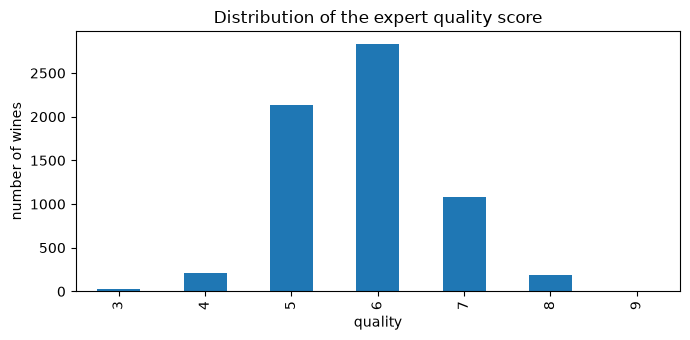

class balance for `quality >= 6`:
quality
1    0.633
0    0.367
Name: proportion, dtype: float64


In [5]:
ax = raw['quality'].value_counts().sort_index().plot(kind='bar', figsize=(7, 3.5))
ax.set_title('Distribution of the expert quality score')
ax.set_xlabel('quality')
ax.set_ylabel('number of wines')
plt.tight_layout()
plt.show()

binary = (raw['quality'] >= 6).astype(int)
print('class balance for `quality >= 6`:')
print(binary.value_counts(normalize=True).round(3))


Scores 3–9 are heavily concentrated on 5 and 6, so a 7-class problem is mostly noise.
Splitting at 6 gives a **~63 / 37 split** — imbalanced enough to be interesting, balanced
enough to train on directly (the pipeline additionally uses class-weighted estimators).


## 3. Outliers


In [6]:
features = [c for c in raw.select_dtypes('number').columns if c != 'quality']

q1 = raw[features].quantile(0.25)
q3 = raw[features].quantile(0.75)
iqr = q3 - q1

for multiplier in (1.5, 3.0):
    mask = ((raw[features] < (q1 - multiplier * iqr)) | (raw[features] > (q3 + multiplier * iqr))).any(axis=1)
    print(f'{multiplier:>4} x IQR -> {mask.sum():5d} rows removed ({mask.mean():.1%})')


 1.5 x IQR ->  1473 rows removed (22.7%)
 3.0 x IQR ->   304 rows removed (4.7%)


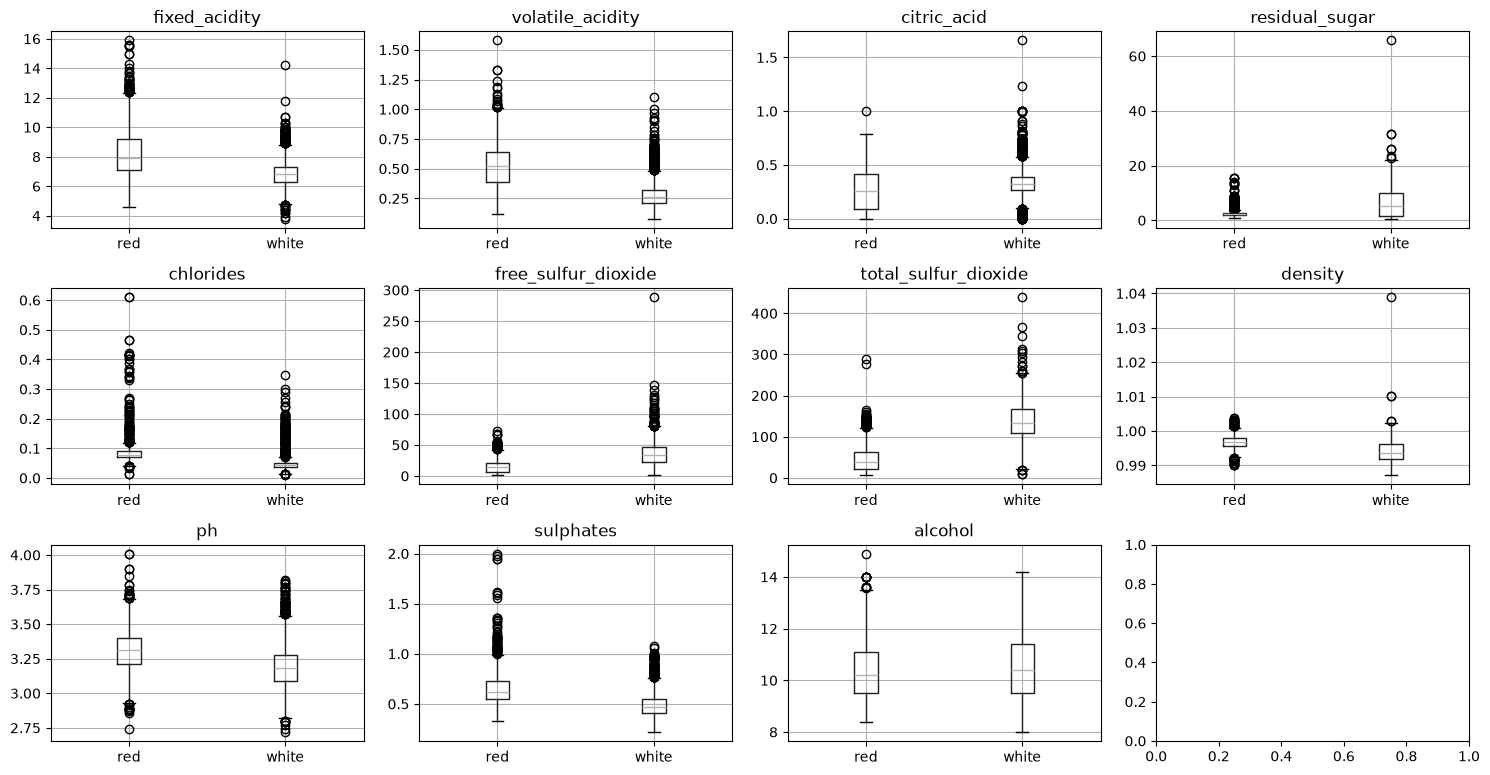

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for ax, column in zip(axes.ravel(), features):
    raw.boxplot(column=column, by='wine_type', ax=ax)
    ax.set_title(column)
    ax.set_xlabel('')
fig.suptitle('')
plt.tight_layout()
plt.show()


The classic 1.5·IQR fence would delete ~20 % of the data — far too aggressive for a
dataset whose tails are genuine wine chemistry. The pipeline therefore uses **3·IQR**
(≈5 % of the rows) and caps the removal at 15 % (`params.yaml → data.max_outlier_fraction`).


## 4. Which features carry the signal?


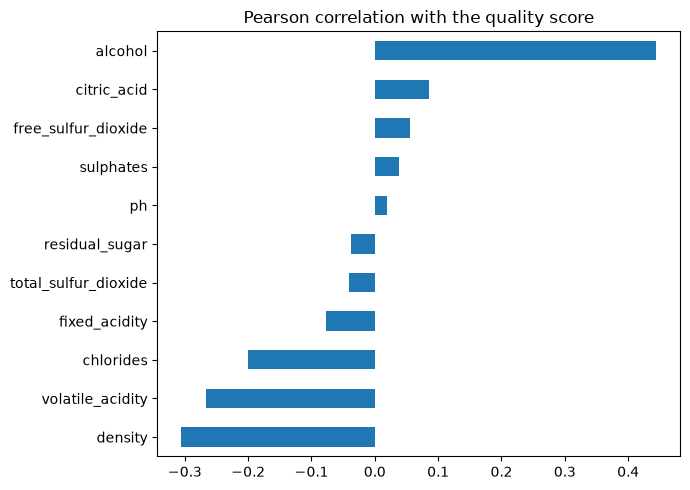

density                -0.306
volatile_acidity       -0.266
chlorides              -0.201
fixed_acidity          -0.077
total_sulfur_dioxide   -0.041
residual_sugar         -0.037
ph                      0.020
sulphates               0.038
free_sulfur_dioxide     0.055
citric_acid             0.086
alcohol                 0.444
Name: quality, dtype: float64

In [8]:
corr = raw[features + ['quality']].corr()['quality'].drop('quality').sort_values()
ax = corr.plot(kind='barh', figsize=(7, 5))
ax.set_title('Pearson correlation with the quality score')
plt.tight_layout()
plt.show()
corr.round(3)


`alcohol` is by far the strongest single predictor, followed by `density` and
`volatile_acidity` (vinegary taste) — which motivates the engineered ratios below.


## 5. Engineered features

The exact transformer that is embedded in the deployed model artifact.


In [9]:
from features import ENGINEERED_FEATURES, add_engineered_features

enriched = add_engineered_features(raw)
enriched[ENGINEERED_FEATURES].describe().T


,count,mean,std,min,25%,50%,75%,max
total_acidity,6497.0,7.873606,1.388024,4.130000,7.020000,7.600000,8.380000,17.045000
acidity_ratio,6497.0,25.338031,10.734086,4.807688,17.692262,23.999904,31.052550,89.998875
bound_sulfur_dioxide,6497.0,85.219255,45.422872,3.000000,55.000000,86.000000,116.000000,331.000000
free_sulfur_ratio,6497.0,0.286768,0.124645,0.022727,0.202073,0.269767,0.348837,0.857143
sugar_alcohol_ratio,6497.0,0.544638,0.510343,0.056604,0.170000,0.283186,0.812500,5.623931
sulphates_chlorides_ratio,6497.0,11.059466,4.546519,1.594679,8.055332,10.269993,13.174394,47.139490
alcohol_density_index,6497.0,10.550310,1.222379,8.025030,9.527812,10.354454,11.395713,14.935831


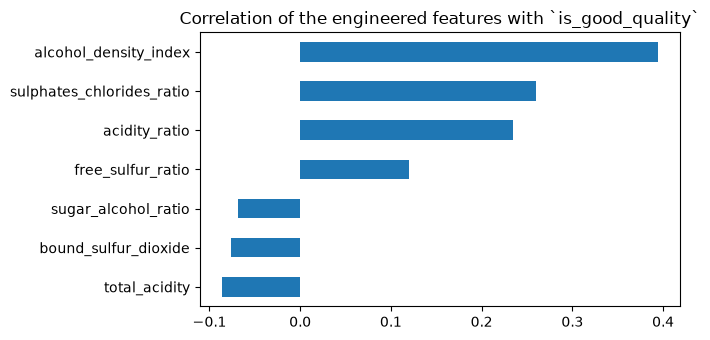

total_acidity               -0.087
bound_sulfur_dioxide        -0.077
sugar_alcohol_ratio         -0.068
free_sulfur_ratio            0.120
acidity_ratio                0.234
sulphates_chlorides_ratio    0.260
alcohol_density_index        0.395
dtype: float64

In [10]:
target = (raw['quality'] >= 6).astype(int)
signal = enriched[ENGINEERED_FEATURES].corrwith(target).sort_values()
ax = signal.plot(kind='barh', figsize=(7, 3.5))
ax.set_title('Correlation of the engineered features with `is_good_quality`')
plt.tight_layout()
plt.show()
signal.round(3)


## 6. Conclusions fed back into the pipeline

| Observation | Implementation |
| --- | --- |
| 1 177 exact duplicates | dropped in `prepare_data.clean_data` |
| no missing values today, but the loader must be robust | median-per-wine-type imputation |
| 1.5·IQR is too aggressive, 3·IQR is reasonable | `params.yaml → data.iqr_multiplier: 3.0` |
| the quality score is concentrated on 5–6 | binary target `quality >= 6` |
| alcohol/density/volatile acidity dominate | ratio features in `code/models/features.py` |
| classes are imbalanced (~63/37) | class-weighted candidates + **F1** as the selection metric |
